<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_3_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**bold text**# Algebra lineal con **SciPy**

Referencias:

* https://docs.scipy.org/doc/scipy/reference/linalg.html
* https://www.datacamp.com/cheat-sheet/scipy-cheat-sheet-linear-algebra-in-python

## **Ejercicio 1)** Importando librerías

Importe las librerías `numpy` para operar con arrays, `scipy` para utilizar rutinas de algebra lineal y `matplotlib.pyplot` para graficar.

In [ ]:
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

## **Ejercicio 2)** Inversa de una matriz

Referencias:

* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.inv.html#scipy.linalg.inv

**1)** Use `linalg.inv()` para calcular la inversa $A^{-1}$ de la matriz

\begin{equation}
A = \bigg(
\begin{array}{cc}
1 & 2 \\
3 & 4
\end{array}
\bigg)
\end{equation}

**2)** Use `np.dot()` para chequear que $A^{-1}A \approx \mathbb{I}$, donde $\mathbb{I}$ es la matriz identidad.

**3)** Chequee que $AA^{-1} \approx \mathbb{I}$.

In [ ]:
# 2.1)
a=np.array([[1, 2], [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [ ]:
linalg.inv(a)

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [ ]:
# 2.2)
np.dot(linalg.inv(a), a)

array([[1.00000000e+00, 0.00000000e+00],
       [1.11022302e-16, 1.00000000e+00]])

In [ ]:
# 2.3)
np.allclose(np.dot(linalg.inv(a), a), np.identity(2)) # Devuelve True si dos matrices son iguales en elementos dentro de una tolerancia.

True

## **Ejercicio 3)** Sistema de ecuaciones lineales

Referencias:

* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve.html#scipy.linalg.solve

**1)** Use `linalg.solve()` para resolver el sistema $Ax=b$ donde, $x$ es la incógnita,

\begin{equation}
A = \left(
\begin{array}{cc}
3 & 2 & 0 \\
1 & -1 & 0 \\
0 & 5 & 1
\end{array}
\right)
\end{equation}

y

\begin{equation}
b = \left(
\begin{array}{cc}
2 \\
4 \\
1
\end{array}
\right)
\end{equation}

**2)** Chequee que $Ax=b$.

In [ ]:
# 3.1)
a=np.array([[3,2,0], [1, -1, 0], [0, 5, 1]])
b=np.array([2, 4, 1])
x=linalg.solve(a, b)
x

array([ 2., -2., 11.])

In [ ]:
# 3.2)
np.dot(a, x)

array([2., 4., 1.])

In [ ]:
np.allclose(np.dot(a, x), b)

True

## **Ejercicio 4)** Cuadrados mínimos

Dada una matriz $X$ de dimensiones $n\times m$ y un vector $y$ de dimensión $n$, la función `linalg.lstsq(X,y,...)` se usa para encontrar el vector $y$ de dimensión $m$ que minimize la norma L2 $|y-Xc|$. Notar que minimizar esta cantidad no necesariamente implica que $Xc=y$. Minimizar $|y-Xc|$ es útil para infinidad de problemas. En particular, es útil para ajustar polinomios a datos.

Referencias:

* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html#scipy.linalg.lstsq

**1)** Use `linalg.lstsq(X,y)` para encontrar los coeficientes $c_0, $c_1 y $c_2$ del polinomio $p(x)=c_0+c_1x+c_2x^2$ que ajuste lo mejor posible los siguientes datos

    x = np.array([1.0, 2.5, 3.5, 4.0, 5.0, 7.0, 8.5])
    y = np.array([0.3, 1.1, 1.5, 2.0, 3.2, 6.6, 8.6])

de acuerdo al método de cuadrados mínimos

\begin{eqnarray}
\min_{c_0,c_1,c_2} \sum_i (y_i-p(x_i))^2
\end{eqnarray}

**Ayuda:** Utilizar la matriz $X$ de entradas $X_{ij}=x_i^j$, i.e. la $j$-ésima potencia de $x_i$.

**2)** Con el fin de evaluar la bondad del ajuste, grafique en una misma figura:

* con símbolos los datos y
* con una curva el polinomio ajustado.

In [ ]:
# 4.1)
x = np.array([1.0, 2.5, 3.5, 4.0, 5.0, 7.0, 8.5])
y = np.array([0.3, 1.1, 1.5, 2.0, 3.2, 6.6, 8.6])

# armemos ahora la matriz X que llamaremos M
# en la primera fila ponemos cada valor de x a la 0, en al segunda a la 1 y en la tercera a la 2

# para eso usamos np.newaxis, que agrega un nuevo eje. Si lo usamos x[:, np.newaxis], vuelve a x un vector columna y agrega una segunda columna:
x[:, np.newaxis]

array([[1. ],
       [2.5],
       [3.5],
       [4. ],
       [5. ],
       [7. ],
       [8.5]])

In [ ]:
# si yo elevo x[...] a una matriz con np.newaxis, entonces las columnas tendrán el x a la correspondiente potencia, por ejemplo:
x[:, np.newaxis]**[1, 2]

array([[ 1.  ,  1.  ],
       [ 2.5 ,  6.25],
       [ 3.5 , 12.25],
       [ 4.  , 16.  ],
       [ 5.  , 25.  ],
       [ 7.  , 49.  ],
       [ 8.5 , 72.25]])

In [ ]:
# con esta intro, ahora hacemos:
M = x[:, np.newaxis]**[0, 1, 2]
M

array([[ 1.  ,  1.  ,  1.  ],
       [ 1.  ,  2.5 ,  6.25],
       [ 1.  ,  3.5 , 12.25],
       [ 1.  ,  4.  , 16.  ],
       [ 1.  ,  5.  , 25.  ],
       [ 1.  ,  7.  , 49.  ],
       [ 1.  ,  8.5 , 72.25]])

In [ ]:
# ahora con esta matriz, debemos ver los cuadrados mínimos de M.dot(p)=y
sp.linalg.lstsq(M, y)

(array([0.0578403 , 0.07701453, 0.11262261]),
 0.3954624919193899,
 3,
 array([94.14628205,  4.12516865,  0.63091939]))

In [ ]:
# me devuelve el primer arreglo que me da la forma de c0, c1, c2; residuos, rank y s (no se que son estos 3 pero no importan)
p = sp.linalg.lstsq(M, y)[0]
p

array([0.0578403 , 0.07701453, 0.11262261])

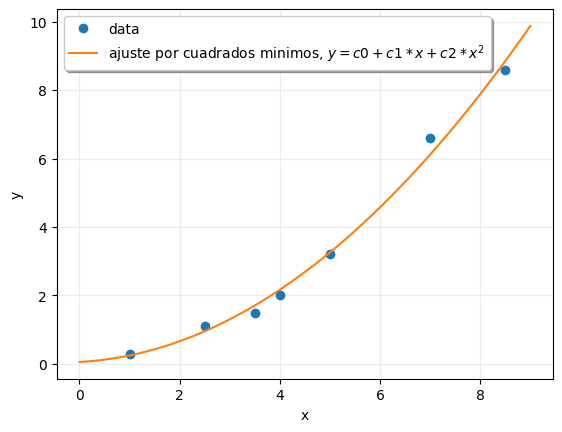

In [ ]:
# 4.2)
# ahora veamos si ajusta bien con un grafico
plt.plot(x, y, 'o', label='data') # grafico los puntos
xx = np.linspace(0, 9, 101)
yy = p[0] + p[1]*xx + p[2]*xx**2
plt.plot(xx, yy, label='ajuste por cuadrados minimos, $y = c0 + c1*x + c2*x^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(framealpha=1, shadow=True)
plt.grid(alpha=0.25)
plt.show()

## **Ejercicio 5)** pseudo-inversa de Moore-Penrose de una matriz

La pseudo-inversa de Moore-Penrose es una generalización de la noción de inversa, que resulta útil porque existe para cualquier matriz de dimensiones y entradas arbitrarias sobre los números reales o complejos.

Si una matriz $A$ es invertible (y por ende cuadrada), existe una matriz $B$ tal $AB=BA=\mathbb{I}$. Dicha matríz $B$ es única (para la $A$ dada) y, por ende, se la denota por $A^{-1}$ y se la denomina inversa de $A$.

Si $A$ no es invertible, luego no existe una matriz $B$ para la cual se cumpla la primera condición $AB=BA=\mathbb{I}$. Sin embargo, se puede ver que siempre existe una matriz $B$ para la cual se cumple $ABA = A$ y $BAB=B$. Dicha matriz $B$ es única (para la $A$ dada) y, por ende, se la denota por $A^+$ y se la denomina matríz pseudo-inversa de Moore-Penrose de $A$.

Referencias:

* https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.pinv.html#scipy.linalg.pinv

**1)** Cree una matriz $A$ de dimensiones $n\times m$ con $n=9$ y $m=6$ de números aleatorios generados a partir de la distribución normal de media 0 y varianza 1.

**2)** Use `linalg.pinv()` para computar la psuedo-inversa de Moore-Penrose $A^+$ de $A$.

**3)** Que dimensiones tiene $A^+$?

**4)** Use `np.allclose()` para verifique que $AA^+A\approx A$.

**5)** Verifique que $A^+AA^+\approx A^+$.

In [ ]:
# 5.1)
# uso sigma * np.random.randn(...) + mu
A = 1*np.random.randn(9, 6)+0
A

array([[ 0.64753106, -1.94293418,  1.10939956, -0.4728136 ,  0.46042259,
        -1.79359824],
       [-2.42064285,  1.70366489,  0.62391212,  0.67012951, -1.09754269,
         1.06349569],
       [-1.48472612,  1.37164051, -0.5336465 , -0.21727579,  0.36933233,
        -1.11267791],
       [-0.74596474,  1.03854223,  0.03334843,  2.8983667 ,  2.04920444,
         0.54193178],
       [ 1.33388848,  0.28672787,  1.10736781,  1.20129016, -0.89411674,
         0.64314975],
       [ 0.28622275, -0.05416472, -1.87541415, -2.37738402, -1.87417385,
        -0.20820607],
       [ 1.3982935 , -0.93264073, -1.02203553, -0.76435668, -1.19143102,
        -0.06027888],
       [-0.99146925,  0.49566616,  0.40673036, -0.36026483,  0.43911305,
         1.65153031],
       [ 1.39098532,  1.14793313,  0.92180035, -1.73217436,  2.46550696,
        -2.00319534]])

In [ ]:
# 5.2)
B = sp.linalg.pinv(A)
B

array([[-0.12583183, -0.11799821, -0.10034461,  0.02708074,  0.20794687,
         0.02552984,  0.10747086, -0.06355086,  0.12156549],
       [-0.20761474,  0.1168473 ,  0.10999873,  0.02667376,  0.18369554,
         0.06543351,  0.00438311, -0.07528167,  0.18402207],
       [ 0.15579051,  0.17077627, -0.07695754, -0.17571451,  0.16814298,
        -0.14536606, -0.11048149,  0.08257656,  0.08688246],
       [ 0.00350898, -0.00770052,  0.05501954,  0.16479061,  0.09977863,
        -0.0701501 ,  0.02748786, -0.19793294, -0.11789556],
       [-0.02615976, -0.15633286, -0.05949998,  0.12133858, -0.1863148 ,
        -0.05704342, -0.03971196,  0.1648047 ,  0.08947931],
       [-0.15210164, -0.055589  , -0.2203472 , -0.00493715, -0.02431015,
        -0.01136197,  0.00619701,  0.3038183 , -0.0277993 ]])

In [ ]:
# 5.3)
np.shape(B)

(6, 9)

In [ ]:
# al reves que A
np.shape(A)

(9, 6)

In [ ]:
# 5.4)
np.allclose(np.dot(np.dot(A, B), A), A)

True

In [ ]:
# 5.5)
np.allclose(np.dot(np.dot(B, A), B), B)

True

## **Ejercicio 6)** Producto de Kronecker

Considere las matrices

\begin{equation}
A = \left(
\begin{array}{cc}
A_{11} & \dots & A_{1m} \\
\vdots & \ddots & \vdots \\
A_{nm} & \dots & A_{nm}
\end{array}
\right)
\end{equation}

y

\begin{equation}
B = \left(
\begin{array}{cc}
B_{11} & \dots & B_{1s} \\
\vdots & \ddots & \vdots \\
B_{r1} & \dots & B_{rs}
\end{array}
\right)
\end{equation}

El producto de Kronecker es la matriz de dimensiones $nr\times ms$ dada por

\begin{equation}
A\otimes B
=
\left(
\begin{array}{cc}
A_{11}B & \dots & A_{1m}B \\
\vdots & \ddots & \vdots \\
A_{n1}B & \dots & A_{nm}B
\end{array}
\right)
=
\left(
\begin{array}{cc}
B_{11}A & \dots & B_{1s}A \\
\vdots & \ddots & \vdots \\
B_{r1}A & \dots & B_{rs}A
\end{array}
\right)
\end{equation}

donde $A_{ij}B$ es un bloque de la matriz $A\otimes B$ igual al producto del escalar $A_{ij}$ por la matriz $B$.
Idem para $B_{ij}A$.

Referencias:

* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.kron.html#scipy.linalg.kron

**1)** Use `linalg.kron()` para calcular el producto de Kronecker de las matrices

\begin{equation}
A = \left(
\begin{array}{cc}
1 & 2 \\
3 & 4 \\
\end{array}
\right)
\end{equation}

y

\begin{equation}
B = \left(
\begin{array}{cc}
1 \\
1 \\
1 \\
\end{array}
\right)
\end{equation}

Que dimensiones tiene $A\otimes B$ en este caso?

**2)** Repita para las matrices

\begin{equation}
A = \left(
\begin{array}{cc}
1 & 2 \\
3 & 4 \\
\end{array}
\right)
\end{equation}

y

\begin{equation}
B = \left(
\begin{array}{cc}
1 & 1 & 1
\end{array}
\right)
\end{equation}

Que dimensiones tiene $A\otimes B$ en este otro caso?

In [ ]:
# 6.1)
A = np.array([[1, 2],
             [3, 4]])
B = np.array([[1],
              [2],
              [3]])

sp.linalg.kron(A, B)

array([[ 1,  2],
       [ 2,  4],
       [ 3,  6],
       [ 3,  4],
       [ 6,  8],
       [ 9, 12]])

In [ ]:
np.shape(sp.linalg.kron(A, B))

(6, 2)

In [ ]:
# 6.2)
A = np.array([[1, 2],
             [3, 4]])
B = np.array([[1, 2, 3]])

sp.linalg.kron(A, B)

array([[ 1,  2,  3,  2,  4,  6],
       [ 3,  6,  9,  4,  8, 12]])

In [ ]:
np.shape(sp.linalg.kron(A, B))

(2, 6)

## **Ejercicio 7)** Autovalores y autovectores
**Hay algo mal en los autovectores a izq**

Considere una matriz $A$ de $n\times m$. Luego, existen un conjunto de escalares $\{\lambda_1,...,\lambda_n\}$ y un correspondiente conjunto de vectores distintos $\{v_1,...,v_n\}$ tales que

\begin{eqnarray}
Av_i = \lambda_i v_i \;\;\;\; (1)
\end{eqnarray}

para todo $i\in\{1,...,n\}$. Estos $\lambda_i$ y $v_i$ se denominan autovalores y autovectores a derecha de $A$, respectivamente. Los autovalores pueden repetirse, pueden ser nulos y se los suele ordenar de mayor a menor en orden descendiente de sus valores absolutos: $|\lambda_1|\geq |\lambda_2|\geq ...\geq |\lambda_n|\geq 0$. Los autovectores pueden normalizarse, ya que si $v_i$ es autovector, luego $v_i/|v_i|$ también lo es.

Los autovectores constituyen una base del dominio de $A$. Esto es muy útil porque permite escribir cualquier vector $v$ en el dominio de $A$ como una combinación linal de sus autovectores

\begin{eqnarray}
v = \sum_i c_i v_i
\end{eqnarray}

Luego, calcular el producto de $A$ con $v$ resulta muy simple

\begin{eqnarray}
Av = A\left(\sum_i c_i v_i\right) = \sum_i c_iAv_i = \sum_i c_i\lambda_iv_i
\end{eqnarray}

Análogamente, existen un conjunto de escalares $\{\mu_1,...,\mu_m\}$ y un correspondiente conjunto de vectores diferentes $\{u_1,...,u_m\}$ de $A$, llamados autovalores y autovectores a izquierda de $A$, respectivamente, y son tales que

\begin{eqnarray}
u_jA = \mu_j u_j \;\;\;\; (2)
\end{eqnarray}

para todo $j\in\{1,...,m\}$.

**1)** Use `linalg.eigvals()` para calcular los autovalores a derecha de la matriz

\begin{equation}
A = \left(
\begin{array}{cc}
0 & -1 \\
1 &  0
\end{array}
\right)
\end{equation}

Referencias:

* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eig.html#scipy.linalg.eig

**2)** Use `linalg.eig()` para calcular los autovalores y los correspondientes autovectores a derecha de $A$.

**3)** Verifique que la ecuación $(1)$ se cumple.

**4)** Use `linalg.eig()` para calcular los autovalores y los correspondientes autovectores a izquierda de $A$.

**5)** Verifique que la ecuación $(2)$ se cumple.

In [ ]:
# 7.1 y 2)
A =np.array([[0, -1],
             [1, 0]])
linalg.eig(A)

(array([0.+1.j, 0.-1.j]),
 array([[0.70710678+0.j        , 0.70710678-0.j        ],
        [0.        -0.70710678j, 0.        +0.70710678j]]))

In [ ]:
autovalores, autovectores = linalg.eig(A)

In [ ]:
# el autovector asociado al autovalor landa_i es la columna i
val0, val1 = autovalores
vect0 = autovectores[..., 0]
vect1 = autovectores[..., 1]

In [ ]:
# 7.3)
A.dot(vect0)==val0*vect0

array([ True,  True])

In [ ]:
A.dot(vect1)==val1*vect1

array([ True,  True])

In [ ]:
# 7.4)
linalg.eig(A, left=True, right=False)

(array([0.+1.j, 0.-1.j]),
 array([[-0.70710678+0.j        , -0.70710678-0.j        ],
        [ 0.        +0.70710678j,  0.        -0.70710678j]]))

In [ ]:
autovalores, autovectores = linalg.eig(A, left=True, right=False)
# el autovector asociado al autovalor landa_i es la columna i
val0, val1 = autovalores
vect0 = autovectores[..., 0]
vect1 = autovectores[..., 1]

In [ ]:
# 7.5)
vect0.dot(A)==val0*vect0

array([False, False])

In [ ]:
vect1.dot(A)==val1*vect1

array([False, False])

## **Ejercicio 8)** Singular Value Decomposition (SVD)

Una matriz compleja $A$ de dimensiones $n\times m$ se la puede pensar como una transformación lineal $A:V\to W$ desde un espacio vectorial $V$ de dimensión $m$ a un espacio vectorial $W$ de dimensión $n$.
A $V$ se lo suele llamar espacio de salida y a $W$ espacio de llegada.

Cualquiera sea $A$, siempre existen matrices $L$, $D$ y $R$, de dimensiones $n\times n$, $n\times m$ y $m\times m$, respectivamente, tales que $L$ y $R$ son unitarias, $D$ es diagonal y

\begin{eqnarray}
A = LDR^{\dagger} \;\;\;\; (1)
\end{eqnarray}

Los valores diagonales

\begin{eqnarray}
\sigma_i := D_{ii}
\end{eqnarray}

están definidos para todo $i\in \{1,...,k\}$, donde $k=\min(n,m)$,
se los denomina valores singulares de $A$, son todos reales y no-negativos.
La descomposición siempre puede realizarse de manera tal que $\sigma_1\geq \sigma_2 \geq ... \geq \sigma_k\geq 0$.
El número de valores singulares no nulos es el rango de $A$.

Los vectores columna $l_1,...,l_n$ de $L$ forman una base ortonormal del espacio vectorial de llegada $W$.
Los vectores columna $r_1,...,r_m$ de $R$ forman una base ortonormal del espacio vectorial de salida $V$.
Usando estas propiedades, la ecuación $(1)$ puede reescribirse como

\begin{eqnarray}
A = \sum_{i=1}^k \sigma_i \, (l_i \otimes r_i^{\dagger}) \;\;\;\; (2)
\end{eqnarray}

donde $l_i \otimes r_i^{\dagger}$ es la matriz de dimensiones $n\times m$ resultante del producto de Kronecker entre la matriz $l_i$ de dimensiones $n\times 1$ y la matriz $r_i^{\dagger}$ de dimensiones $1\times m$.

Referencias:

* https://en.wikipedia.org/wiki/Singular_value_decomposition
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.svd.html#scipy.linalg.svd

**1)** Cree una matriz compleja $A$ de dimensiones $n\times m$ con $n=9$ y $m=6$, cuyas entradas $a_{ij} = x_{ij} + i y_{ij}$ se computen generando números aleatorios $x_{ij}$ e $y_{ij}$ a partir de una distribución normal de media 0 y varianza 1.

**2)** Use `linalg.svd()` para calcular la SVD de $A$. Dicha función retorna 3 arrays, digamos `L`, `s` y `Rc`, donde `L` denota a la matriz $L$, `s` denota al vector de valores singulares $(\sigma_1,\sigma_2,...,\sigma_k)$ y `Rc` denota a la matriz compleja conjugada $R^{\dagger}$.
Inspeccione las dimensiones de los arrays retornados.

**3)** Use el vector `s` para crear la matriz diagonal $D$ de dimensiones $n\times m$.

**4)** Use `np.allclose()` para verificar numéricamente la ecuación $(1)$.

In [ ]:
# 6.1)